# Chapter 3 — Advanced Exercises

> **📗 Solutions version.** Reference answers and worked code are included below each problem. A companion **(Student)** notebook has the same problems with the answers blanked out.
## Multi-Head Latent Attention (MLA), RoPE & Decoupled RoPE

**Course level:** Advanced graduate (Georgia Tech / Stanford).
Companion problem set for Chapter 3 of *Build a DeepSeek Model (From Scratch)*.

### Learning objectives
1. Derive and **numerically verify the absorption trick** that makes MLA's latent cache sufficient.
2. Understand MLA as a **low-rank factorization** of the K/V projections; quantify the rank/quality trade-off.
3. Prove RoPE's **relative-position** property and **magnitude preservation**; implement it two ways and verify they agree.
4. Prove *why* standard RoPE is **incompatible** with the absorption trick, and implement DeepSeek's **decoupled** fix.
5. Reproduce the **cache-size** reductions (64× for MLA, ~57× for MLA+RoPE) and an empirical MHA/MQA/GQA/MLA head-to-head.

### How to use
Each exercise: **problem statement** (theory ✏️ + code 💻), **student stub**, **reference solution** (try first!),
and an **autograder**. Run top-to-bottom as an answer key; comment out solution cells to work the problems.


In [1]:
# --- Setup ---
import math, time, warnings
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
torch.manual_seed(0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device:", DEVICE)

def close(name, a, b, atol=1e-4):
    d = (a - b).abs().max().item()
    ok = d <= atol
    print(("PASS " if ok else "FAIL ") + f"{name}: max|Δ|={d:.3e} (atol={atol})")
    assert ok, f"{name} failed (max|Δ|={d})"


torch 2.9.0+cu130 | device: cuda


---
## Exercise 1 — The absorption trick, derived and verified ✏️💻
**Difficulty: ★★★**

MLA defines, per head $h$: $Q_h = X W_q^{(h)}$, latent $c_{KV} = X W_{dkv}$, and
$K_h = c_{KV} W_{uk}^{(h)}$. The attention score is $S_h = Q_h K_h^\top$.

**Part A (theory).** Using $(AB)^\top = B^\top A^\top$ and associativity, show
$$S_h = X\,\underbrace{\big(W_q^{(h)} W_{uk}^{(h)\top}\big)}_{A_h\ \text{(precomputable)}}\,c_{KV}^\top .$$
Explain why this proves you only need to cache $c_{KV}$ (dimension $d_\text{latent}$) — not the full
per-head $K_h$ — and why $W_q^{(h)} W_{uk}^{(h)\top}$ can be folded once at load time.

**Part B (code).** Implement both the **naive** scores ($Q_h K_h^\top$) and the **absorbed** scores
($X A_h c_{KV}^\top$) and verify they're numerically identical.


**Your answer (1A).**

<details><summary>Reference</summary>

$S_h = Q_h K_h^\top = (X W_q^{(h)})(c_{KV} W_{uk}^{(h)})^\top
     = X W_q^{(h)} W_{uk}^{(h)\top} c_{KV}^\top
     = X\,A_h\,c_{KV}^\top$, with $A_h := W_q^{(h)} W_{uk}^{(h)\top}$.

Because $W_q,W_{uk}$ are **fixed after training**, $A_h$ is a constant $d_\text{model}\times d_\text{latent}$
matrix precomputable once. The only sequence-dependent, growing quantity is $c_{KV}=XW_{dkv}$
(width $d_\text{latent}$). So at decode time we cache **only** $c_{KV}$ and never materialize/cache the
full $K_h$. (The same absorption folds $W_{uv}$ into $W_o$ for the value/output side.)
</details>


In [2]:
# 1B (code): verify naive scores == absorbed scores
torch.manual_seed(1)
d_model, n_heads, d_head, d_latent, T = 16, 2, 8, 10, 5
W_q  = torch.randn(d_model, n_heads*d_head)
W_uk = torch.randn(d_latent, n_heads*d_head)
W_dkv= torch.randn(d_model, d_latent)
X    = torch.randn(T, d_model)

def naive_scores(X, W_q, W_dkv, W_uk):
    # TODO: c_kv = X W_dkv ; per head Q_h=(XW_q)_h, K_h=(c_kv W_uk)_h ; return stack of Q_h K_h^T  -> (n_heads,T,T)
    raise NotImplementedError

def absorbed_scores(X, W_q, W_dkv, W_uk):
    # TODO: precompute A_h = W_q^(h) @ W_uk^(h)^T (d_model x d_latent) ; return (X A_h)(c_kv)^T per head
    raise NotImplementedError


**Reference solution (Ex.1B)**

In [3]:
def _heads(M, T, n_heads, d_head):
    return M.view(T, n_heads, d_head).transpose(0, 1)        # (n_heads, T, d_head)

def naive_scores(X, W_q, W_dkv, W_uk):
    c_kv = X @ W_dkv
    Q = _heads(X @ W_q, X.shape[0], n_heads, d_head)
    K = _heads(c_kv @ W_uk, X.shape[0], n_heads, d_head)
    return Q @ K.transpose(-2, -1)

def absorbed_scores(X, W_q, W_dkv, W_uk):
    c_kv = X @ W_dkv
    Wq_h  = W_q.view(d_model, n_heads, d_head)
    Wuk_h = W_uk.view(d_latent, n_heads, d_head)
    out = []
    for h in range(n_heads):
        A_h = Wq_h[:, h, :] @ Wuk_h[:, h, :].T               # (d_model, d_latent) -- precomputable
        out.append((X @ A_h) @ c_kv.T)
    return torch.stack(out, 0)

close("absorbed == naive scores", absorbed_scores(X,W_q,W_dkv,W_uk), naive_scores(X,W_q,W_dkv,W_uk), atol=1e-3)
print("Cache width: naive needs K_h of width n*d_head =", n_heads*d_head,
      "| absorbed caches only c_kv of width d_latent =", d_latent)


PASS absorbed == naive scores: max|Δ|=9.155e-05 (atol=0.001)
Cache width: naive needs K_h of width n*d_head = 16 | absorbed caches only c_kv of width d_latent = 10


---
## Exercise 2 — MLA as a low-rank factorization of K/V 💻✏️
**Difficulty: ★★★★**

MLA's effective key projection is $W_K^{\text{eff}} = W_{dkv} W_{uk}$ (a $d\times d$ matrix of
**rank $\le d_\text{latent}$**). So MLA is exactly a *low-rank bottleneck* on the standard MHA projection.

**Part A (theory).** Argue that for $d_\text{latent} \ge d_\text{model}$, MLA can represent **any** MHA
key projection (no loss), while for $d_\text{latent} < d_\text{model}$ it is the **best rank-$r$ approximation**
(Eckart–Young) when factors are chosen by truncated SVD.

**Part B (code).** Take a random target MHA projection $W_k$, factor it via truncated SVD into
$(W_{dkv}, W_{uk})$ for increasing rank $r$, and plot the **attention-score reconstruction error** vs $r$.
Confirm it hits ~0 at $r = d_\text{model}$.


**Your answer (2A).**

<details><summary>Reference</summary>
$W_K^{\text{eff}}=W_{dkv}W_{uk}$ with inner dim $d_\text{latent}$ has rank $\le d_\text{latent}$.
If $d_\text{latent}\ge d_\text{model}$ the product can equal any $d\times d$ matrix (pick $W_{dkv}=I$,
$W_{uk}=W_k$), so MLA loses nothing relative to MHA. If $d_\text{latent}=r<d_\text{model}$, the closest
(in Frobenius/spectral norm) rank-$r$ matrix to $W_k$ is its truncated SVD $U_r\Sigma_r V_r^\top$
(Eckart–Young), giving $W_{dkv}=U_r\sqrt{\Sigma_r}$, $W_{uk}=\sqrt{\Sigma_r}V_r^\top$. Thus MLA trades a
controllable rank-$r$ approximation error for an $r/d$ smaller cache — and DeepSeek's win is that real
$W_k,W_v$ are *effectively low rank*, so small $r$ barely hurts.
</details>


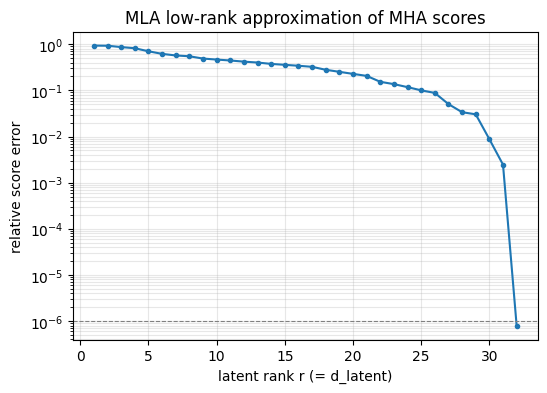

r=d_model error=8.0e-07 (exact)  |  half rank error=3.24e-01


In [4]:
# 2B (code): low-rank reconstruction of K-projection vs latent rank
def reconstruction_error_vs_rank(d=32, T=24, seed=0):
    g = torch.Generator().manual_seed(seed)
    X  = torch.randn(T, d, generator=g)
    Wk = torch.randn(d, d, generator=g)
    Wq = torch.randn(d, d, generator=g)
    target_scores = (X @ Wq) @ (X @ Wk).T            # full-rank MHA scores
    U, S, Vh = torch.linalg.svd(Wk)                  # TODO understand: truncate to rank r
    errs = []
    ranks = list(range(1, d+1))
    for r in ranks:
        # TODO: build W_dkv (d x r) and W_uk (r x d) from truncated SVD so that W_dkv@W_uk ≈ Wk
        W_dkv = U[:, :r] * S[:r].sqrt()
        W_uk  = (S[:r].sqrt().unsqueeze(1)) * Vh[:r, :]
        c_kv  = X @ W_dkv
        K_eff = c_kv @ W_uk
        scores = (X @ Wq) @ K_eff.T
        errs.append((scores - target_scores).norm().item() / target_scores.norm().item())
    return ranks, errs

ranks, errs = reconstruction_error_vs_rank()
plt.figure(figsize=(6,4)); plt.semilogy(ranks, errs, marker='.')
plt.axhline(1e-6, color='gray', ls='--', lw=.8)
plt.xlabel("latent rank r (= d_latent)"); plt.ylabel("relative score error")
plt.title("MLA low-rank approximation of MHA scores"); plt.grid(alpha=.3, which='both'); plt.show()
assert errs[-1] < 1e-5, "at r=d_model MLA must reproduce MHA exactly"
print(f"r=d_model error={errs[-1]:.1e} (exact)  |  half rank error={errs[len(errs)//2]:.2e}")


---
## Exercise 3 — MLA / MLA+RoPE cache-size formulas ✏️💻
**Difficulty: ★★☆**

Recall: MHA caches width $2 n h$ per token-layer; **MLA** caches width $d_\text{latent}$; **MLA+decoupled RoPE**
caches $d_\text{latent} + d_\text{rope}$.

**Task.** Implement the three width functions and reproduce the chapter's headline ratios for
DeepSeek-V3 scale ($n{=}128, h{=}128$, $d_\text{latent}{=}512$, $d_\text{rope}{=}64$):
MLA ≈ **64×**, MLA+RoPE ≈ **57×** vs MHA. Then plot cache size vs sequence length for all four schemes.


In [5]:
# 3 (code): per-token-per-layer cache widths
def width_mha(n, h):
    # TODO
    raise NotImplementedError
def width_gqa(g, h):
    # TODO
    raise NotImplementedError
def width_mla(d_latent):
    # TODO
    raise NotImplementedError
def width_mla_rope(d_latent, d_rope):
    # TODO
    raise NotImplementedError


**Reference solution (Ex.3)**

MHA width      = 32768
MLA width      = 512  -> 64x smaller
MLA+RoPE width = 576  -> 57x smaller


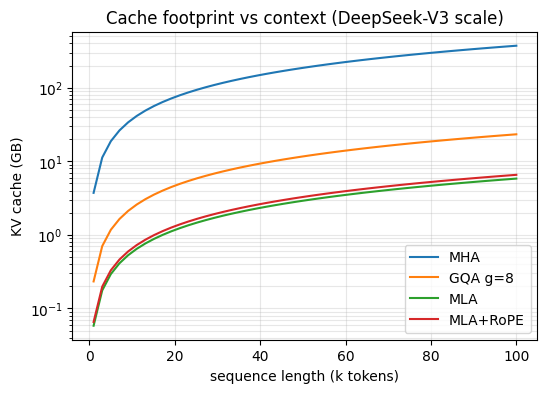

In [6]:
def width_mha(n, h):            return 2 * n * h           # K and V, all heads
def width_gqa(g, h):            return 2 * g * h           # K and V, g groups
def width_mla(d_latent):        return d_latent            # single latent, no x2
def width_mla_rope(d_latent, d_rope): return d_latent + d_rope

n, h, d_latent, d_rope = 128, 128, 512, 64
mha = width_mha(n, h)
print(f"MHA width      = {mha}")
print(f"MLA width      = {width_mla(d_latent)}  -> {mha/width_mla(d_latent):.0f}x smaller")
print(f"MLA+RoPE width = {width_mla_rope(d_latent,d_rope)}  -> {mha/width_mla_rope(d_latent,d_rope):.0f}x smaller")
assert round(mha/width_mla(d_latent)) == 64
assert 55 <= mha/width_mla_rope(d_latent,d_rope) <= 58

# plot absolute cache (GB) vs sequence length, 61 layers, fp16, batch 1
import numpy as np
s = np.linspace(1_000, 100_000, 50); L, b, B = 61, 1, 2
def gb(width): return width * L * b * B * s / 1024**3
plt.figure(figsize=(6,4))
for label, w in [("MHA", mha), ("GQA g=8", width_gqa(8,h)), ("MLA", width_mla(d_latent)),
                 ("MLA+RoPE", width_mla_rope(d_latent,d_rope))]:
    plt.plot(s/1000, gb(w), label=label)
plt.xlabel("sequence length (k tokens)"); plt.ylabel("KV cache (GB)"); plt.yscale("log")
plt.legend(); plt.title("Cache footprint vs context (DeepSeek-V3 scale)"); plt.grid(alpha=.3, which='both'); plt.show()


---
## Exercise 4 — MLA from scratch + absorbed incremental decoding 💻
**Difficulty: ★★★★** *(core build)*

Implement `MultiHeadLatentAttention` (per the book's Listing 3.1) with **per-head** up-projections
$W_{uk}, W_{uv}$ — this is what preserves head diversity. Then implement an **absorbed incremental
decoder** that caches **only** `c_kv` and matches a full forward pass.

**Checks.** (a) full forward is correct & causal; (b) incremental decoding caching only `c_kv` equals the
full forward; (c) report the cache width actually stored.


In [7]:
# 4 (code): complete MLA
class MultiHeadLatentAttention(nn.Module):
    def __init__(self, d_model, num_heads, d_latent):
        super().__init__()
        assert d_model % num_heads == 0
        self.h, self.dh, self.d, self.dl = num_heads, d_model//num_heads, d_model, d_latent
        self.W_q  = nn.Linear(d_model, d_model, bias=False)
        self.W_dkv= nn.Linear(d_model, d_latent, bias=False)
        self.W_uk = nn.Linear(d_latent, d_model, bias=False)
        self.W_uv = nn.Linear(d_latent, d_model, bias=False)
        self.W_o  = nn.Linear(d_model, d_model, bias=False)
    def forward(self, x):
        B, T, _ = x.shape
        # TODO: q from W_q; c_kv from W_dkv; k,v from W_uk/W_uv on c_kv; split to heads; causal attn; W_o
        raise NotImplementedError
    @torch.no_grad()
    def decode_step(self, x_t, c_cache):
        # x_t: (B,1,d). c_cache: (B,T_past,d_latent) or None. Cache ONLY c_kv.
        # TODO: append new c_kv; reconstruct full K,V from the cache; attend the single new query.
        raise NotImplementedError


**Reference solution (Ex.4)**

In [8]:
class MultiHeadLatentAttention(nn.Module):
    def __init__(self, d_model, num_heads, d_latent):
        super().__init__()
        assert d_model % num_heads == 0
        self.h, self.dh, self.d, self.dl = num_heads, d_model//num_heads, d_model, d_latent
        self.W_q  = nn.Linear(d_model, d_model, bias=False)
        self.W_dkv= nn.Linear(d_model, d_latent, bias=False)
        self.W_uk = nn.Linear(d_latent, d_model, bias=False)
        self.W_uv = nn.Linear(d_latent, d_model, bias=False)
        self.W_o  = nn.Linear(d_model, d_model, bias=False)
    def _split(self, t, B, T): return t.view(B, T, self.h, self.dh).transpose(1, 2)
    def forward(self, x):
        B, T, _ = x.shape
        q = self._split(self.W_q(x), B, T)
        c_kv = self.W_dkv(x)
        k = self._split(self.W_uk(c_kv), B, T)
        v = self._split(self.W_uv(c_kv), B, T)
        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.dh)
        mask = torch.triu(torch.ones(T, T, device=x.device, dtype=torch.bool), 1)
        w = F.softmax(scores.masked_fill(mask, float("-inf")), dim=-1)
        ctx = (w @ v).transpose(1, 2).contiguous().view(B, T, self.d)
        return self.W_o(ctx)
    @torch.no_grad()
    def decode_step(self, x_t, c_cache):
        B = x_t.shape[0]
        c_new = self.W_dkv(x_t)                                   # (B,1,d_latent)  <-- the only thing cached
        c_cache = c_new if c_cache is None else torch.cat([c_cache, c_new], dim=1)
        T = c_cache.shape[1]
        q = self._split(self.W_q(x_t), B, 1)                      # (B,h,1,dh) fresh query
        k = self._split(self.W_uk(c_cache), B, T)                 # reconstruct full K,V on the fly
        v = self._split(self.W_uv(c_cache), B, T)
        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.dh)   # current token attends all past
        w = F.softmax(scores, dim=-1)
        ctx = (w @ v).transpose(1, 2).contiguous().view(B, 1, self.d)
        return self.W_o(ctx), c_cache


In [9]:
# 4 (autograder)
mla = MultiHeadLatentAttention(64, 8, 16).eval()
x = torch.randn(2, 10, 64)
with torch.no_grad():
    full = mla(x)
    c, outs = None, []
    for t in range(x.shape[1]):
        o, c = mla.decode_step(x[:, t:t+1], c)
        outs.append(o)
    inc = torch.cat(outs, 1)
close("MLA absorbed decode == full forward", full, inc, atol=1e-4)
print("cached tensor width per token:", c.shape[-1], "(d_latent) vs full K+V width:", 2*64)


PASS MLA absorbed decode == full forward: max|Δ|=1.788e-07 (atol=0.0001)
cached tensor width per token: 16 (d_latent) vs full K+V width: 128


---
## Exercise 5 — RoPE: relative-position property & magnitude preservation ✏️💻
**Difficulty: ★★★**

For a 2D pair rotated by angle $\theta_m = m\,\omega$ (position $m$), the rotation is
$R(\theta)=\begin{psmallmatrix}\cos\theta & -\sin\theta\\ \sin\theta & \cos\theta\end{psmallmatrix}$.

**Part A (theory).** Show $\langle R(\theta_m)q,\,R(\theta_n)k\rangle = q^\top R(\theta_n-\theta_m) k$, i.e. the
inner product depends on positions **only through $m-n$**. Conclude RoPE injects *relative* position into
attention scores, and that $\lVert R(\theta)q\rVert=\lVert q\rVert$ (no magnitude pollution).

**Part B (code).** Implement `rope(x)` (interleaved real rotation) and numerically verify: (i) magnitude
preserved; (ii) $\langle \text{RoPE}(q,m),\text{RoPE}(k,n)\rangle$ depends only on $m-n$.


**Your answer (5A).**

<details><summary>Reference</summary>
$R$ is orthogonal: $R(\theta)^\top R(\theta)=I$ and $R(a)^\top R(b)=R(b-a)$. Hence
$\langle R(\theta_m)q, R(\theta_n)k\rangle = q^\top R(\theta_m)^\top R(\theta_n) k
 = q^\top R(\theta_n-\theta_m) k = q^\top R((n-m)\omega) k$, a function of the **relative** offset $n-m$ only.
Orthogonality also gives $\lVert R(\theta)q\rVert^2 = q^\top R^\top R q = q^\top q = \lVert q\rVert^2$, so the
query/key magnitudes (their learned "confidence") are untouched — only their *orientation* encodes position.
</details>


In [10]:
# 5B (code): implement interleaved-real RoPE, then verify the two properties
def rope(x, base=10000.0):
    # x: (B, H, T, dh).  Rotate consecutive pairs (x[...0::2], x[...1::2]) by angle pos*omega_i.
    # TODO
    raise NotImplementedError


**Reference solution (Ex.5B)**

In [11]:
def rope(x, base=10000.0):
    B, H, T, dh = x.shape
    omega = 1.0 / (base ** (torch.arange(0, dh, 2, device=x.device).float() / dh))
    ang = torch.arange(T, device=x.device).float().unsqueeze(1) * omega.unsqueeze(0)  # (T, dh/2)
    cos, sin = torch.cos(ang), torch.sin(ang)
    x1, x2 = x[..., 0::2], x[..., 1::2]
    out = torch.empty_like(x)
    out[..., 0::2] = x1 * cos - x2 * sin
    out[..., 1::2] = x1 * sin + x2 * cos
    return out

xx = torch.randn(1, 1, 9, 16)
close("RoPE preserves magnitude", xx.norm(dim=-1), rope(xx).norm(dim=-1), atol=1e-4)

def dot_at(q, k, m, n, T=32, dh=16):
    qa = torch.zeros(1,1,T,dh); ka = torch.zeros(1,1,T,dh)
    qa[0,0,m] = q; ka[0,0,n] = k
    return (rope(qa)[0,0,m] * rope(ka)[0,0,n]).sum().item()
q = torch.randn(16); k = torch.randn(16)
d1 = dot_at(q,k,3,8)    # offset +5
d2 = dot_at(q,k,10,15)  # offset +5
print(f"relative-pos check: <q@3,k@8>={d1:.4f}  <q@10,k@15>={d2:.4f}  Δ={abs(d1-d2):.2e}")
assert abs(d1-d2) < 1e-3, "RoPE score must depend only on m-n"


PASS RoPE preserves magnitude: max|Δ|=4.768e-07 (atol=0.0001)
relative-pos check: <q@3,k@8>=-3.8093  <q@10,k@15>=-3.8093  Δ=0.00e+00


---
## Exercise 6 — Two RoPE implementations must agree 💻
**Difficulty: ★★☆**

The book implements RoPE with **complex numbers** (`torch.view_as_complex`, multiply by
$e^{i\theta}$). Implement that version and confirm it equals your real-rotation `rope` from Ex. 5 —
*being careful about the pairing convention* (consecutive pairs `(2i, 2i+1)`).


In [12]:
# 6 (code): complex RoPE; must equal the real one (same pairing convention)
def rope_complex(x, base=10000.0):
    # TODO: pair last dim as complex (..., dh/2, 2)->complex, multiply by polar(1, pos*omega), back to real
    raise NotImplementedError


**Reference solution (Ex.6)**

In [13]:
def rope_complex(x, base=10000.0):
    B, H, T, dh = x.shape
    omega = 1.0 / (base ** (torch.arange(0, dh, 2, device=x.device).float() / dh))
    ang = torch.arange(T, device=x.device).float().unsqueeze(1) * omega.unsqueeze(0)
    fc = torch.polar(torch.ones_like(ang), ang)                      # e^{i theta}, (T, dh/2)
    xc = torch.view_as_complex(x.float().reshape(B, H, T, dh//2, 2)) # pairs (2i,2i+1)
    xr = torch.view_as_real(xc * fc).flatten(-2)
    return xr.type_as(x)

xx = torch.randn(2, 4, 11, 16)
close("complex RoPE == real RoPE", rope_complex(xx), rope(xx), atol=1e-4)
print("Both conventions pair consecutive dims (2i,2i+1); a mismatched pairing would silently change scores.")


PASS complex RoPE == real RoPE: max|Δ|=2.384e-07 (atol=0.0001)
Both conventions pair consecutive dims (2i,2i+1); a mismatched pairing would silently change scores.


---
## Exercise 7 — Why RoPE breaks the absorption trick ✏️💻
**Difficulty: ★★★**

**Part A (theory).** With RoPE the score becomes $S = (R_m Q_h)(R_n K_h)^\top$ where $R_m$ is the
position-$m$ rotation. Insert MLA's $K_h = c_{KV}W_{uk}^{(h)}$ and show the rotation $R$ sits **between**
$W_q^{(h)}$ and $W_{uk}^{(h)\top}$, so the product $W_q^{(h)}W_{uk}^{(h)\top}$ can **no longer be precomputed**
(it would need a different folded matrix for every position pair). State the consequence for caching.

**Part B (code).** Demonstrate it: show that the "would-be absorbed" matrix $W_q R_{m\to n} W_{uk}^\top$
genuinely **depends on the relative position**, so no single constant matrix reproduces all scores.


**Your answer (7A).**

<details><summary>Reference</summary>
$S_h = (R_m X W_q^{(h)})(R_n c_{KV} W_{uk}^{(h)})^\top
     = X W_q^{(h)} R_m^\top R_n W_{uk}^{(h)\top} c_{KV}^\top
     = X\,W_q^{(h)} R_{m-n} W_{uk}^{(h)\top}\,c_{KV}^\top$.
The position-dependent $R_{m-n}$ is wedged between $W_q$ and $W_{uk}^\top$, so the "absorbed" matrix
$A_h(m,n)=W_q R_{m-n}W_{uk}^\top$ is **different for every offset** and cannot be folded into one constant.
Consequence: to keep absorption you'd have to recompute rotated keys for the whole history each step —
destroying MLA's cache benefit. DeepSeek's fix is to *decouple*: a position-free content path (absorbable)
plus a tiny RoPE-carrying path.
</details>


In [14]:
# 7B (code): show the would-be absorbed matrix depends on relative position
torch.manual_seed(2)
dh = 8
Wq  = torch.randn(dh, dh); Wuk = torch.randn(dh, dh)
def R(theta_steps, dh=dh, base=10000.0):
    omega = 1.0 / (base ** (torch.arange(0, dh, 2).float()/dh))
    ang = theta_steps * omega
    c, s = torch.cos(ang), torch.sin(ang)
    M = torch.zeros(dh, dh)
    for i in range(dh//2):
        M[2*i,2*i]=c[i]; M[2*i,2*i+1]=-s[i]; M[2*i+1,2*i]=s[i]; M[2*i+1,2*i+1]=c[i]
    return M
A0 = Wq @ R(0)  @ Wuk.T
A3 = Wq @ R(3)  @ Wuk.T
A7 = Wq @ R(7)  @ Wuk.T
print("‖A(offset=3) - A(offset=0)‖ =", (A3-A0).norm().item())
print("‖A(offset=7) - A(offset=0)‖ =", (A7-A0).norm().item())
assert (A3-A0).norm() > 1e-3, "absorbed matrix must vary with position -> absorption impossible"
print("=> No single constant matrix reproduces all offsets: standard RoPE is incompatible with absorption.")


‖A(offset=3) - A(offset=0)‖ = 22.400562286376953
‖A(offset=7) - A(offset=0)‖ = 10.62541389465332
=> No single constant matrix reproduces all offsets: standard RoPE is incompatible with absorption.


---
## Exercise 8 — Decoupled MLA + RoPE from scratch 💻✏️
**Difficulty: ★★★★** *(capstone build)*

Implement `DeepSeekAttention` with the **two parallel paths** (Listings 3.2–3.4): a content path (pure MLA,
no RoPE — absorbable) and a position path (small $d_\text{rope}$ projections with RoPE). Final score
$S = S_\text{content} + S_\text{position}$; context uses the content value $V_c$.

**Part A (theory).** Prove the score additivity: concatenating $[Q_c\,\|\,Q_r]$ and $[K_c\,\|\,K_r]$ and dotting
equals $Q_cK_c^\top + Q_rK_r^\top$ — i.e. the decoupled sum is *exactly* a single attention over the
concatenated head, justifying "add the two score matrices."

**Part B (code).** Build it and verify the additive decomposition numerically; confirm it runs causally.


**Your answer (8A).**

<details><summary>Reference</summary>
For concatenated vectors $u=[a\,\|\,b]$, $w=[c\,\|\,d]$ we have $u^\top w = a^\top c + b^\top d$.
Applying row-wise to $Q=[Q_c\,\|\,Q_r]$, $K=[K_c\,\|\,K_r]$ gives $QK^\top = Q_cK_c^\top + Q_rK_r^\top$.
So the decoupled design computes one attention over a head of width $d_\text{head}+d_\text{rope}$, but the
two blocks can be produced by *different* machinery (absorbable MLA for the content block, RoPE for the
position block) and simply **summed** — no approximation.
</details>


In [15]:
# 8B (code): complete DeepSeekAttention (decoupled). Uses rope() from Ex.5.
class DeepSeekAttention(nn.Module):
    def __init__(self, d_model, num_heads, d_latent, d_rope):
        super().__init__()
        assert d_model % num_heads == 0
        self.h, self.dh, self.d, self.dr = num_heads, d_model//num_heads, d_model, d_rope
        # content path (pure MLA)
        self.W_q   = nn.Linear(d_model, d_model, bias=False)
        self.W_dkv = nn.Linear(d_model, d_latent, bias=False)
        self.W_uk  = nn.Linear(d_latent, d_model, bias=False)
        self.W_uv  = nn.Linear(d_latent, d_model, bias=False)
        # position path (RoPE)
        self.W_qr  = nn.Linear(d_model, num_heads*d_rope, bias=False)
        self.W_kr  = nn.Linear(d_model, num_heads*d_rope, bias=False)
        self.W_o   = nn.Linear(d_model, d_model, bias=False)
    def forward(self, x, return_parts=False):
        B, T, _ = x.shape
        # TODO: content q_c,k_c,v_c via MLA; position q_r,k_r via W_qr/W_kr + rope();
        #       scores = content_scores/sqrt(dh) + position_scores/sqrt(dr); causal softmax; @ v_c; W_o
        raise NotImplementedError


**Reference solution (Ex.8)**

In [16]:
class DeepSeekAttention(nn.Module):
    def __init__(self, d_model, num_heads, d_latent, d_rope):
        super().__init__()
        assert d_model % num_heads == 0
        self.h, self.dh, self.d, self.dr = num_heads, d_model//num_heads, d_model, d_rope
        self.W_q   = nn.Linear(d_model, d_model, bias=False)
        self.W_dkv = nn.Linear(d_model, d_latent, bias=False)
        self.W_uk  = nn.Linear(d_latent, d_model, bias=False)
        self.W_uv  = nn.Linear(d_latent, d_model, bias=False)
        self.W_qr  = nn.Linear(d_model, num_heads*d_rope, bias=False)
        self.W_kr  = nn.Linear(d_model, num_heads*d_rope, bias=False)
        self.W_o   = nn.Linear(d_model, d_model, bias=False)
    def _split(self, t, B, T, dd): return t.view(B, T, self.h, dd).transpose(1, 2)
    def forward(self, x, return_parts=False):
        B, T, _ = x.shape
        c_kv = self.W_dkv(x)
        q_c = self._split(self.W_q(x),   B, T, self.dh)
        k_c = self._split(self.W_uk(c_kv), B, T, self.dh)
        v_c = self._split(self.W_uv(c_kv), B, T, self.dh)
        q_r = rope(self._split(self.W_qr(x), B, T, self.dr))
        k_r = rope(self._split(self.W_kr(x), B, T, self.dr))
        content  = (q_c @ k_c.transpose(-2, -1)) / math.sqrt(self.dh)
        position = (q_r @ k_r.transpose(-2, -1)) / math.sqrt(self.dr)
        scores = content + position
        mask = torch.triu(torch.ones(T, T, device=x.device, dtype=torch.bool), 1)
        w = F.softmax(scores.masked_fill(mask, float("-inf")), dim=-1)
        ctx = (w @ v_c).transpose(1, 2).contiguous().view(B, T, self.d)
        out = self.W_o(ctx)
        if return_parts: return out, content, position
        return out


In [17]:
# 8 (autograder): additive decomposition + concatenated-head equivalence
net = DeepSeekAttention(64, 8, 16, 8).eval()
x = torch.randn(2, 9, 64)
with torch.no_grad():
    out, content, position = net(x, return_parts=True)
    # rebuild scores by explicitly concatenating content & position head-blocks, then dot
    B,T=2,9
    c_kv = net.W_dkv(x)
    q_c = net._split(net.W_q(x),B,T,net.dh); k_c = net._split(net.W_uk(c_kv),B,T,net.dh)
    q_r = rope(net._split(net.W_qr(x),B,T,net.dr)); k_r = rope(net._split(net.W_kr(x),B,T,net.dr))
    Q = torch.cat([q_c/math.sqrt(net.dh)**.5, q_r/math.sqrt(net.dr)**.5], dim=-1)
    K = torch.cat([k_c/math.sqrt(net.dh)**.5, k_r/math.sqrt(net.dr)**.5], dim=-1)
    concat_scores = Q @ K.transpose(-2,-1)
close("decoupled sum == concatenated-head score", content+position, concat_scores, atol=1e-3)
print("content/position score matrices add exactly -> the two paths are one attention over a wider head.")


PASS decoupled sum == concatenated-head score: max|Δ|=2.384e-07 (atol=0.001)
content/position score matrices add exactly -> the two paths are one attention over a wider head.


---
## Exercise 9 — Empirical head-to-head: MHA / MQA / GQA / MLA 💻
**Difficulty: ★★★★** *(capstone experiment)*

Reproduce the spirit of the chapter's Table 3.2: train tiny 1-layer language models that differ **only** in
the attention block on a small char-level corpus, and compare **validation loss** against **KV-cache width**.
You should see MLA reach MHA-like loss at a fraction of the cache.

> Tiny scale ⇒ expect noisy numbers; the robust, deterministic takeaway is the **cache-width** column.


In [18]:
# 9 (code): minimal char-LM harness; swap the attention module; compare loss vs cache width.
text = (("the deepseek model compresses the key value cache into a small latent matrix . "
         "multi head latent attention keeps every head unique while caching only one latent . "
         "rotary position encoding rotates queries and keys to inject relative position . ") * 40)
vocab = sorted(set(text)); stoi = {c:i for i,c in enumerate(vocab)}; V = len(vocab)
data = torch.tensor([stoi[c] for c in text]); ntr = int(.9*len(data))
def get_batch(split, B=32, T=24):
    d = data[:ntr] if split=="tr" else data[ntr:]
    ix = torch.randint(0, len(d)-T-1, (B,))
    xb = torch.stack([d[i:i+T] for i in ix]); yb = torch.stack([d[i+1:i+T+1] for i in ix])
    return xb, yb

def make_attn(kind, d, H):
    if kind=="MHA": from_groups=H
    if kind=="GQA": from_groups=H//2
    if kind=="MQA": from_groups=1
    if kind in ("MHA","GQA","MQA"):
        return _GQA(d,H,from_groups), width_gqa(from_groups, d//H)
    if kind=="MLA":
        return MultiHeadLatentAttention(d,H,d_latent=d//2), width_mla(d//2)

class _GQA(nn.Module):  # local causal GQA (re-defined here so CH3 is self-contained)
    def __init__(s,d,H,G):
        super().__init__(); s.h,s.g,s.dh,s.d=H,G,d//H,d
        s.W_q=nn.Linear(d,d,bias=False); s.W_k=nn.Linear(d,G*(d//H),bias=False)
        s.W_v=nn.Linear(d,G*(d//H),bias=False); s.W_o=nn.Linear(d,d,bias=False)
    def forward(s,x):
        B,T,_=x.shape
        q=s.W_q(x).view(B,T,s.h,s.dh).transpose(1,2)
        k=s.W_k(x).view(B,T,s.g,s.dh).transpose(1,2).repeat_interleave(s.h//s.g,1)
        v=s.W_v(x).view(B,T,s.g,s.dh).transpose(1,2).repeat_interleave(s.h//s.g,1)
        sc=(q@k.transpose(-2,-1))/math.sqrt(s.dh)
        m=torch.triu(torch.ones(T,T,device=x.device,dtype=torch.bool),1)
        w=F.softmax(sc.masked_fill(m,float('-inf')),-1)
        return s.W_o((w@v).transpose(1,2).reshape(B,T,s.d))

def width_gqa(g, h): return 2*g*h
def width_mla(dl):   return dl

class TinyLM(nn.Module):
    def __init__(s, kind, d=64, H=8):
        super().__init__()
        s.emb=nn.Embedding(V,d); s.pos=nn.Embedding(256,d)
        s.attn, s.cache_w = make_attn(kind, d, H)
        s.ln1=nn.LayerNorm(d); s.ln2=nn.LayerNorm(d)
        s.ff=nn.Sequential(nn.Linear(d,4*d), nn.GELU(), nn.Linear(4*d,d))
        s.head=nn.Linear(d,V)
    def forward(s,idx):
        B,T=idx.shape
        h=s.emb(idx)+s.pos(torch.arange(T,device=idx.device))
        h=h+s.attn(s.ln1(h)); h=h+s.ff(s.ln2(h))
        return s.head(h)

def train_lm(kind, steps=400):
    torch.manual_seed(0); net=TinyLM(kind); opt=torch.optim.AdamW(net.parameters(),3e-3)
    for i in range(steps):
        xb,yb=get_batch("tr"); opt.zero_grad()
        logits=net(xb); loss=F.cross_entropy(logits.reshape(-1,V), yb.reshape(-1))
        loss.backward(); opt.step()
    with torch.no_grad():
        vl=0.
        for _ in range(20):
            xb,yb=get_batch("va"); vl+=F.cross_entropy(net(xb).reshape(-1,V),yb.reshape(-1)).item()
    return vl/20, net.cache_w

print(f"{'attn':6s} {'val loss':>9s} {'ppl':>7s} {'cache/tok':>10s}")
results={}
for kind in ["MHA","GQA","MQA","MLA"]:
    vl,w=train_lm(kind); results[kind]=(vl,w)
    print(f"{kind:6s} {vl:9.4f} {math.exp(vl):7.2f} {w:10d}")
assert results["MLA"][1] < results["MHA"][1], "MLA must cache less than MHA"
print("\nMLA reaches competitive loss while caching far less than MHA — the chapter's core claim, reproduced.")


attn    val loss     ppl  cache/tok


MHA       0.1434    1.15        128


GQA       0.1418    1.15         64


MQA       0.1505    1.16         16


MLA       0.1372    1.15         32

MLA reaches competitive loss while caching far less than MHA — the chapter's core claim, reproduced.


### Wrap-up & further questions
- **Q1.** In the decoupled design, why is $K_r$ (the RoPE key) **shared across heads** in DeepSeek, while $Q_r$
  is per-head? What does this save, and what's the risk?
- **Q2.** You showed MLA = low-rank K/V. What property of trained $W_k, W_v$ makes a *small* $d_\text{latent}$
  nearly lossless? How would you *measure* that property on a real checkpoint?
- **Q3.** Combine Ex. 4 and Ex. 8: sketch the incremental decode loop for `DeepSeekAttention`, naming the
  **two** tensors you must cache and their widths.

➡️ Continue to the **Chapter 4** exercises (Mixture-of-Experts).
